In [1]:
!hostname

node47


In [2]:
!pwd

/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing


In [3]:
!ls

gravitational_lensing.ipynb  mock_lenses_hsc.csv


In [4]:
import pandas as pd

df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


Compute $e_x$ and $e_y$

where :
$$e_x = \text{cos}(2\theta)\frac{1-q^2}{1+q^2} \quad \text{and} \quad e_y = \text{sin}(2\theta)\frac{1-q^2}{1+q^2}$$

and :
$$q = \frac{\sqrt{1 - \sqrt{e_x^2 + e_y^2}}}{\sqrt{1 + \sqrt{e_x^2 + e_y^2}}}$$


In [5]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [6]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

Compute $\gamma_{ext,1}$ and $\gamma_{ext,2}$
where:
$$\gamma_{ext, 1} = \text{cos}(2\theta) \ \gamma_{ext} \quad \text{and} \quad \gamma_{ext, 2} = \text{sin}(2\theta) \ \gamma_{ext}$$
and :
$$\gamma_{ext} = \sqrt{\gamma_{ext, 1}^2 + \gamma_{ext,2}^2}$$

In [7]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

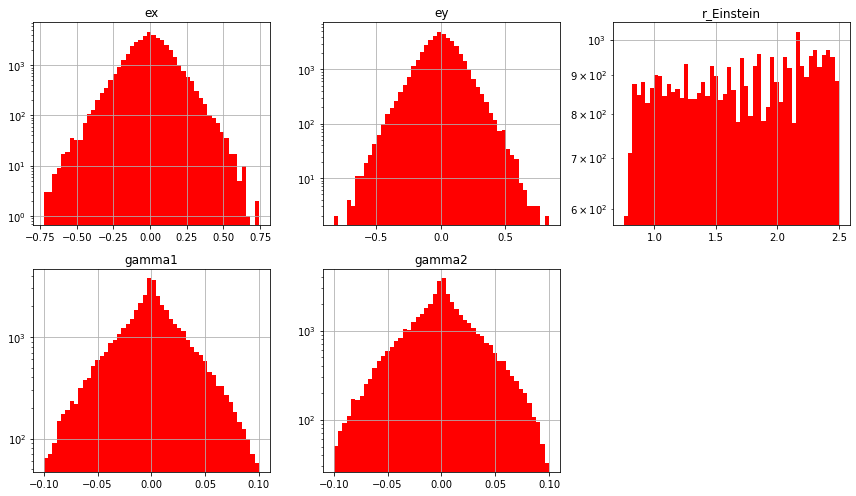

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()   
columns = ["ex", "ey", "r_Einstein", "gamma1", "gamma2"]

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=50, color='red', alpha=1, log=True)
    axes[i].set_title(col)
    axes[i].grid(True)

# axes[-2].axis("off")
axes[-1].axis("off")

plt.tight_layout()
plt.show()


In [9]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [10]:
!pwd

/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_hsc


In [11]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [12]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [13]:
df_im

,objID,location
0,51398,final_hscsearch_2e3_26/lens_51398_source_1143_...
1,50969,final_hscsearch_2e3_26/lens_50969_source_7163_...
2,50571,final_hscsearch_2e3_26/lens_50571_source_19_r_...
3,50855,final_hscsearch_2e3_26/lens_50855_source_7131_...
4,50772,final_hscsearch_2e3_26/lens_50772_source_6472_...
...,...,...
43733,31851,final_hscsearch_2e3_16/lens_31851_source_125_r...
43734,30103,final_hscsearch_2e3_16/lens_30103_source_6947_...
43735,31118,final_hscsearch_2e3_16/lens_31118_source_6536_...
43736,30509,final_hscsearch_2e3_16/lens_30509_source_6682_...


In [14]:
df.columns

Index(['objID', 'objID_src', 'rot', 'x_lens', 'y_lens', 'q', 'PA',
       'r_Einstein', 'z_source', 'z_lens', 'velDisp', 'x_source', 'y_source',
       'boost', 'shear', 'shear_PA', 'ex', 'ey', 'qq', 'diff', 'gamma1',
       'gamma2'],
      dtype='object')

In [15]:
df_im.columns

Index(['objID', 'location'], dtype='object')

In [16]:
df_full = df.merge(df_im, on = "objID", how = 'left')
df_full

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2,location
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,...,-1.0,0.022431,0.911779,-0.106255,0.146359,0.832873,1.110223e-16,-0.005610,0.021719,final_hscsearch_2e3_1/lens_1_source_1090_r_0.fits
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,...,-3.0,0.059983,0.958381,-0.244299,-0.154508,0.742644,-1.110223e-16,-0.020340,0.056429,final_hscsearch_2e3_1/lens_2_source_426_r_0.fits
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,...,-3.0,0.038890,1.134869,0.152219,-0.066075,0.845785,0.000000e+00,-0.025022,0.029771,final_hscsearch_2e3_1/lens_3_source_2136_r_0.fits
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,...,-4.0,0.005173,2.657499,0.038344,-0.147143,0.857919,0.000000e+00,0.002932,-0.004262,final_hscsearch_2e3_1/lens_4_source_7141_r_0.fits
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,...,-4.0,0.043490,1.112804,0.076335,0.073224,0.899268,0.000000e+00,-0.026486,0.034495,final_hscsearch_2e3_1/lens_5_source_7215_r_0.fits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,...,-4.0,0.054220,2.249565,-0.121763,-0.071475,0.867499,0.000000e+00,-0.011475,-0.052992,final_hscsearch_2e3_26/lens_51996_source_1083_...
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,...,-3.0,0.029062,2.235106,0.045068,-0.204716,0.808340,0.000000e+00,-0.006970,-0.028214,final_hscsearch_2e3_26/lens_51997_source_12_r_...
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,...,-1.0,0.045575,2.531362,0.176209,-0.216331,0.750802,-1.110223e-16,0.015642,-0.042806,final_hscsearch_2e3_26/lens_51998_source_11_r_...
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,...,-1.0,0.041806,2.955045,-0.141833,0.067661,0.853459,0.000000e+00,0.038930,-0.015238,final_hscsearch_2e3_26/lens_51999_source_1273_...


In [17]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [18]:
import os
# os.chdir("/home/rcanameras/data/mock_lenses_hsc")
os.chdir("/home/mbatt")

In [19]:
image_index = 9

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_1/lens_12_source_1225_r_0.fits


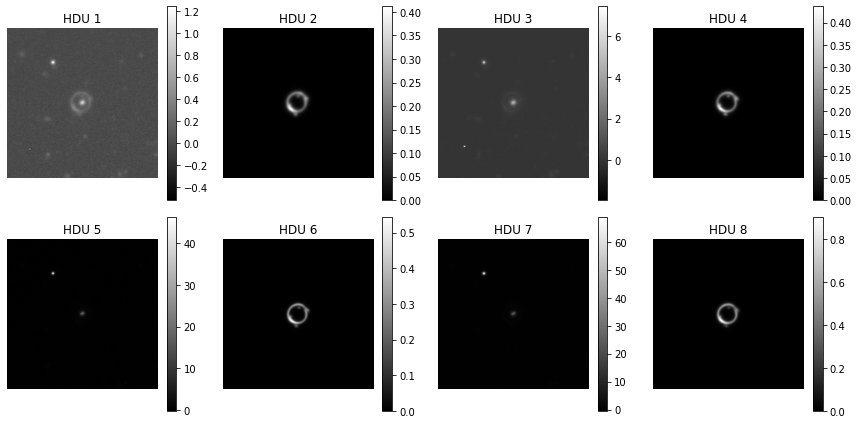

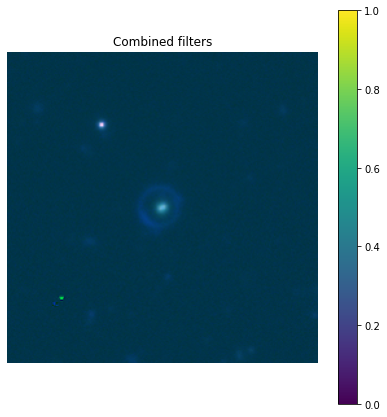

In [20]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_sample.location.values[image_index])
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
    
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"HDU {idx}")
    ax.axis('off')

plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

In [20]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 4 
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [21]:
path_image = "/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_hsc/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data/"

In [29]:
LL = [f for f in os.listdir(save_path)]

In [30]:
len(LL)

43734

In [31]:
LL[0]

'lens_45869_source_1366_r_2.fits.pt'

In [27]:
df_sample.location[0].split('/')[1] + '.pt'

'lens_1_source_1090_r_0.fits.pt'

In [28]:
import random
from tqdm import tqdm
import os

w1, w2 = 40, 180 # image will be of dimension w2-w1 x w2-w1
LL = [f for f in os.listdir(save_path)]

for ima_file in tqdm(df_sample.location):
    if ima_file.split('/')[1] + '.pt' not in LL:
        with fits.open(path_image + ima_file) as hdul:
            c = random.randint(0, w1)
            images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul), 2)]
            arr = np.stack(images, axis=0)
            save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

100%|███████████████████████████████████| 43733/43733 [03:19<00:00, 218.92it/s]


## Reopen modified images

Found FITS: 3001
Opening: /net/CLUSTER/VAULT/users/mbatt/data/lens_34226_source_1990_r_3.fits.pt


/tmp/ipykernel_665623/1475162526.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(file)


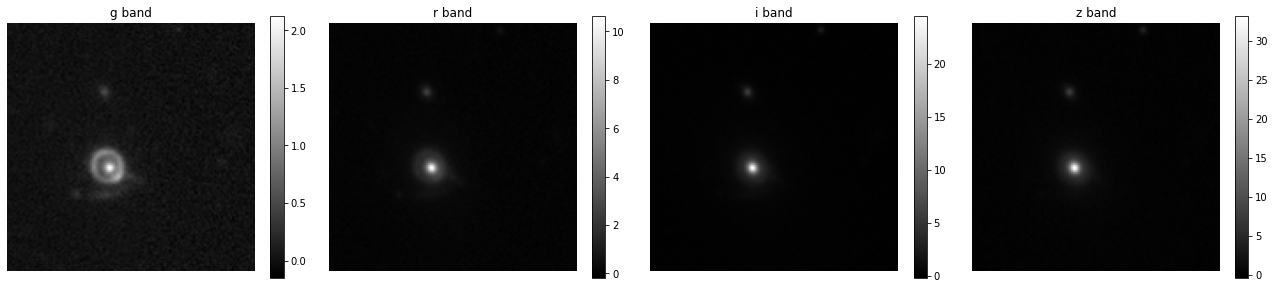

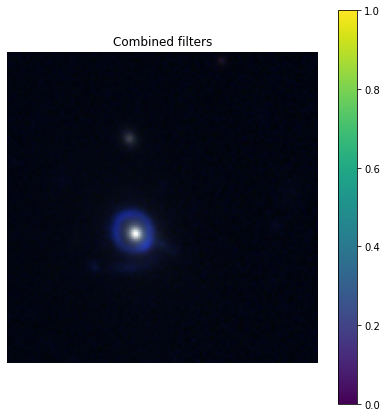

In [66]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder =  "/net/CLUSTER/VAULT/users/mbatt/data/"
fits_files = [f for f in os.listdir(folder)]
print("Found FITS:", len(fits_files))

file = os.path.join(folder, df_sample.location.values[image_index].split("/")[1] + ".pt")
images = torch.load(file)
print("Opening:", file)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{bandes[idx-1]} band")
    ax.axis('off')

plt.tight_layout()
plt.show()

g = images[0]
r = images[1]
i = images[2]
z = images[3]
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

In [21]:
!nvidia-smi

Mon Mar 30 13:25:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:21:00.0 Off |                    0 |
|  0%   24C    P8             20W /  300W |      74MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [22]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [23]:
!python3 -c "import torch; print(torch.__version__)"

2.5.1+cu121


In [24]:
!python3 -c "import torch, os; print(os.path.dirname(torch.__file__))"

/home/mbatt/.local/lib/python3.9/site-packages/torch


In [25]:
# !pip install "numpy<2" --force-reinstall

In [13]:
with fits.open(file) as hdul:
    hdul.info()
    print(hdul[5])

Filename: final_hscsearch_2e3_1/lens_877_source_2649_r_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 ImageHDU         7   (240, 240)   float64   
  2                1 ImageHDU         7   (240, 240)   float64   
  3                1 ImageHDU         7   (240, 240)   float64   
  4                1 ImageHDU         7   (240, 240)   float64   
  5                1 ImageHDU         7   (240, 240)   float64   
  6                1 ImageHDU         7   (240, 240)   float64   
  7                1 ImageHDU         7   (240, 240)   float64   
  8                1 ImageHDU         7   (240, 240)   float64   


# SIMPLE CNN

In [20]:
df_sample

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2,location
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,...,-1.0,0.022431,0.911779,-0.106255,0.146359,0.832873,1.110223e-16,-0.005610,0.021719,final_hscsearch_2e3_1/lens_1_source_1090_r_0.fits
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,...,-3.0,0.059983,0.958381,-0.244299,-0.154508,0.742644,-1.110223e-16,-0.020340,0.056429,final_hscsearch_2e3_1/lens_2_source_426_r_0.fits
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,...,-3.0,0.038890,1.134869,0.152219,-0.066075,0.845785,0.000000e+00,-0.025022,0.029771,final_hscsearch_2e3_1/lens_3_source_2136_r_0.fits
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,...,-4.0,0.005173,2.657499,0.038344,-0.147143,0.857919,0.000000e+00,0.002932,-0.004262,final_hscsearch_2e3_1/lens_4_source_7141_r_0.fits
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,...,-4.0,0.043490,1.112804,0.076335,0.073224,0.899268,0.000000e+00,-0.026486,0.034495,final_hscsearch_2e3_1/lens_5_source_7215_r_0.fits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,...,-4.0,0.054220,2.249565,-0.121763,-0.071475,0.867499,0.000000e+00,-0.011475,-0.052992,final_hscsearch_2e3_26/lens_51996_source_1083_...
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,...,-3.0,0.029062,2.235106,0.045068,-0.204716,0.808340,0.000000e+00,-0.006970,-0.028214,final_hscsearch_2e3_26/lens_51997_source_12_r_...
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,...,-1.0,0.045575,2.531362,0.176209,-0.216331,0.750802,-1.110223e-16,0.015642,-0.042806,final_hscsearch_2e3_26/lens_51998_source_11_r_...
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,...,-1.0,0.041806,2.955045,-0.141833,0.067661,0.853459,0.000000e+00,0.038930,-0.015238,final_hscsearch_2e3_26/lens_51999_source_1273_...


In [21]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

In [26]:
dff

,r_Einstein,gamma1,gamma2,ex,ey
location,,,,,
final_hscsearch_2e3_1/lens_1_source_1090_r_0.fits,0.973810,0.471910,0.609074,0.421740,0.585502
final_hscsearch_2e3_1/lens_2_source_426_r_0.fits,0.981875,0.398249,0.782780,0.327677,0.404629
final_hscsearch_2e3_1/lens_3_source_2136_r_0.fits,0.985922,0.374839,0.649372,0.597865,0.457793
final_hscsearch_2e3_1/lens_4_source_7141_r_0.fits,0.975252,0.514623,0.479055,0.520270,0.409057
final_hscsearch_2e3_1/lens_5_source_7215_r_0.fits,0.998766,0.367519,0.673011,0.546157,0.541536
...,...,...,...,...,...
final_hscsearch_2e3_26/lens_51996_source_1083_r_1.fits,0.015319,0.442579,0.235186,0.411173,0.454547
final_hscsearch_2e3_26/lens_51997_source_12_r_2.fits,0.003908,0.465110,0.359185,0.524852,0.374446
final_hscsearch_2e3_26/lens_51998_source_11_r_0.fits,0.024446,0.578178,0.286159,0.614211,0.367463


# Normalization of the parameters

In [27]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']

dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())


In [34]:
from torch.utils.data import Dataset, DataLoader
from astropy.io import fits
import torch
import numpy as np
import random

class LensDataset(Dataset):
    def __init__(self, df, path_tensor_folder):
        self.df = df
        self.path = path_tensor_folder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # filename stored in df, e.g. "sample_0001.pt"
        tensor_path = os.path.join(self.path, row.name.split('/')[1] + '.pt')

        # load the tensor
        x = torch.load(tensor_path)

        # label
        y = torch.tensor(row.values, dtype=torch.float32)

        return x, y

In [35]:
path_tensor = "/home/mbatt/data/"

dataset = LensDataset(dff, path_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=3)

In [36]:
import torch.nn as nn
import torch

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return torch.relu(out)

class ResNetMini(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_in = nn.Conv2d(4, 16, kernel_size=3, padding=1)
        self.bn_in = nn.BatchNorm2d(16)

        self.block1 = ResidualBlock(16)
        self.pool1 = nn.MaxPool2d(2)

        self.block2 = ResidualBlock(16)
        self.pool2 = nn.MaxPool2d(2)

        self.block3 = ResidualBlock(16)
        self.pool3 = nn.MaxPool2d(2)

        self.fc = nn.Linear(16 * 17 * 17, 5)  # adjust if input size changes

    def forward(self, x):
        x = torch.relu(self.bn_in(self.conv_in(x)))
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)


# dimensions X = [2000, 4, 140, 140]
# then [2000, 8, 140, 140] because padding of 1, and 8 filters of size 3x3
# max pool [2000, 8, 70, 70]
## [2000, 16, 70, 70]
# max pool [2000, 16, 35, 35]

In [37]:
from torch.utils.data import random_split
path_image = "/home/mbatt/data/"
full_dataset = LensDataset(dff, path_image)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [38]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=3)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=3)

In [39]:
len(train_loader)

1094

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetMini().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
val_losses = []

for epoch in range(20):

    # ---- TRAIN ----
    model.train()
    epoch_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_loss += loss.item()

    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")


/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You ar

Epoch 1: train=0.1314, val=0.0301


/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You ar

Epoch 2: train=0.0286, val=0.0251


/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You ar

...

Epoch 18: train=0.0152, val=0.0162


/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You ar

Epoch 19: train=0.0149, val=0.0163


/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You ar

Epoch 20: train=0.0149, val=0.0161


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

model = SimpleCNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

N = len(X)
idx = int(0.8 * N)

X_train, X_val = X[:idx], X[idx:]
y_train, y_val = y[:idx], y[idx:]

batch_size = 32

train_losses = []
val_losses = []

for epoch in range(20):

    # ---- TRAIN ----
    model.train()
    epoch_loss = 0
    for i in range(0, len(X_train), batch_size):
        xb = X_train[i:i+batch_size]
        yb = y_train[i:i+batch_size]

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / (len(X_train) / batch_size))

    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        outputs = model(X_val)
        val_loss = criterion(outputs, y_val).item()
        val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: train={train_losses[-1]:.4f}, val={val_losses[-1]:.4f}")


Epoch 1: train=0.1522, val=0.0376
Epoch 2: train=0.0354, val=0.0335
Epoch 3: train=0.0318, val=0.0334
Epoch 4: train=0.0303, val=0.0338
Epoch 5: train=0.0292, val=0.0345
Epoch 6: train=0.0287, val=0.0344
Epoch 7: train=0.0282, val=0.0353
Epoch 8: train=0.0272, val=0.0350
Epoch 9: train=0.0263, val=0.0357
Epoch 10: train=0.0251, val=0.0361
Epoch 11: train=0.0241, val=0.0375
Epoch 12: train=0.0230, val=0.0385
Epoch 13: train=0.0219, val=0.0385
Epoch 14: train=0.0211, val=0.0389
Epoch 15: train=0.0195, val=0.0390
Epoch 16: train=0.0182, val=0.0415
Epoch 17: train=0.0173, val=0.0426
Epoch 18: train=0.0166, val=0.0473
Epoch 19: train=0.0167, val=0.0415
Epoch 20: train=0.0158, val=0.0442


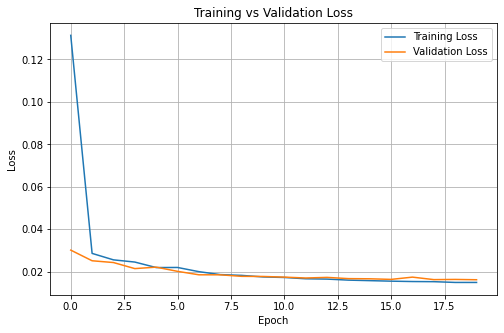

In [41]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [43]:
model.eval()
preds = []
targets = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        out = model(xb)
        preds.append(out.cpu())
        targets.append(yb.cpu())

preds = torch.cat(preds)
targets = torch.cat(targets)


/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x = torch.load(tensor_path)
/tmp/ipykernel_28889/2383232820.py:22: FutureWarning: You ar

In [45]:
dff

,r_Einstein,gamma1,gamma2,ex,ey
location,,,,,
final_hscsearch_2e3_1/lens_1_source_1090_r_0.fits,0.973810,0.471910,0.609074,0.421740,0.585502
final_hscsearch_2e3_1/lens_2_source_426_r_0.fits,0.981875,0.398249,0.782780,0.327677,0.404629
final_hscsearch_2e3_1/lens_3_source_2136_r_0.fits,0.985922,0.374839,0.649372,0.597865,0.457793
final_hscsearch_2e3_1/lens_4_source_7141_r_0.fits,0.975252,0.514623,0.479055,0.520270,0.409057
final_hscsearch_2e3_1/lens_5_source_7215_r_0.fits,0.998766,0.367519,0.673011,0.546157,0.541536
...,...,...,...,...,...
final_hscsearch_2e3_26/lens_51996_source_1083_r_1.fits,0.015319,0.442579,0.235186,0.411173,0.454547
final_hscsearch_2e3_26/lens_51997_source_12_r_2.fits,0.003908,0.465110,0.359185,0.524852,0.374446
final_hscsearch_2e3_26/lens_51998_source_11_r_0.fits,0.024446,0.578178,0.286159,0.614211,0.367463


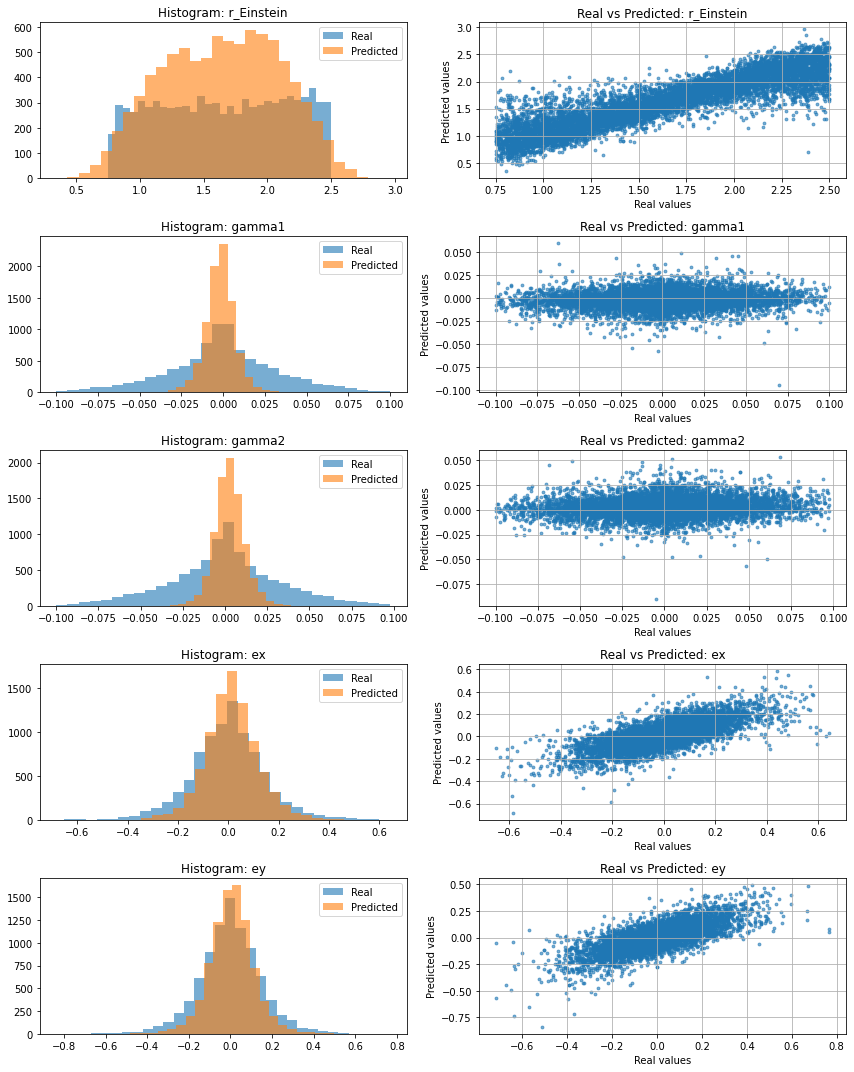

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(12, 15))

for i in range(5):
    # Histogram comparison
    plt.subplot(5, 2, 2*i + 1)
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted")
    plt.title(f"Histogram: {param_names[i]}")
    plt.legend()

    # Scatter plot real vs predicted
    plt.subplot(5, 2, 2*i + 2)
    plt.scatter(y_true_denorm[:, i], y_pred_denorm[:, i], s=8, alpha=0.6)
    plt.xlabel("Real values")
    plt.ylabel("Predicted values")
    plt.title(f"Real vs Predicted: {param_names[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()


In [34]:
!pwd

/home/mbatt


In [43]:
!ls

data	   gravitational_lensing	mock_lenses_hsc.csv
Downloads  gravitational_lensing.ipynb


In [36]:
!cd gravitational_lensing/

In [37]:
!pwd

/home/mbatt


In [45]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [46]:
!pwd

/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing


In [47]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint:
hint: 	git config --global init.defaultBranch <name>
hint:
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint:
hint: 	git branch -m <name>
Initialized empty Git repository in /net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/.git/
